# Mynt Advanced Analytics Project for ML Engineers - Chor Eduarte


#### Problem Definition

Rossmann is Germany's second-largest drug store chain. You are provided with historical sales data for 1,115 Rossmann stores. The task is to forecast the "Sales" column. Note that some stores in the dataset were temporarily closed for refurbishment

#### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

#### Exploring the data

In [2]:
# Load the datasets (ensure the date is parsed correctly)
train = pd.read_csv("train.csv", parse_dates=["Date"])
store = pd.read_csv("store.csv")


C:\Users\MLE\AppData\Local\Temp\ipykernel_1224\27793583.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv", parse_dates=["Date"])


In [3]:
# Display first few rows of each dataset
print(train.head())
print(store.head())

   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          4 2015-04-30   6228        650     1      1            0   
1      2          4 2015-04-30   6884        716     1      1            0   
2      3          4 2015-04-30   9971        979     1      1            0   
3      4          4 2015-04-30  16106       1854     1      1            0   
4      5          4 2015-04-30   6598        729     1      1            0   

   SchoolHoliday  
0              0  
1              0  
2              0  
3              0  
4              0  
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c                620.0                        9.0   
4      5    

In [4]:
# Merge on the Store column
data = pd.merge(train, store, on="Store", how="left")
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914629 entries, 0 to 914628
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      914629 non-null  int64         
 1   DayOfWeek                  914629 non-null  int64         
 2   Date                       914629 non-null  datetime64[ns]
 3   Sales                      914629 non-null  int64         
 4   Customers                  914629 non-null  int64         
 5   Open                       914629 non-null  int64         
 6   Promo                      914629 non-null  int64         
 7   StateHoliday               914629 non-null  object        
 8   SchoolHoliday              914629 non-null  int64         
 9   StoreType                  914629 non-null  object        
 10  Assortment                 914629 non-null  object        
 11  CompetitionDistance        912263 non-null  float64 

##### Sales Distribution

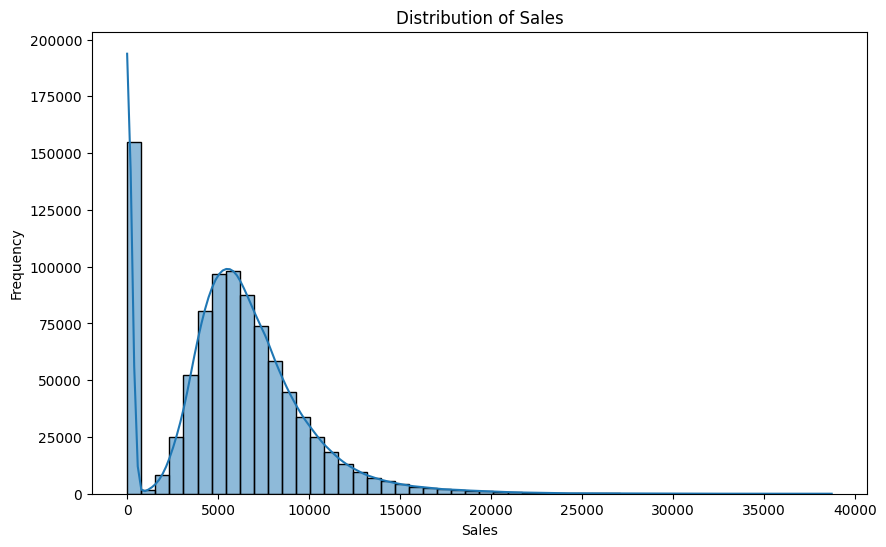

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Sales'], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

##### Time Series Trend

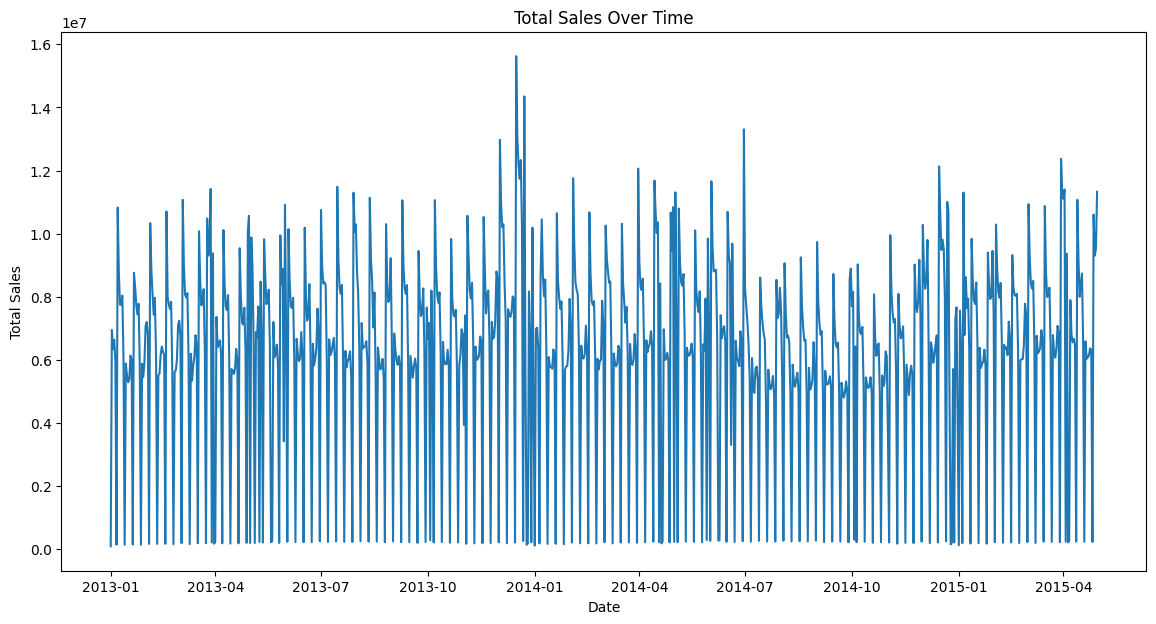

In [6]:
plt.figure(figsize=(14, 7))
plt.plot(data.groupby("Date")["Sales"].sum())
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

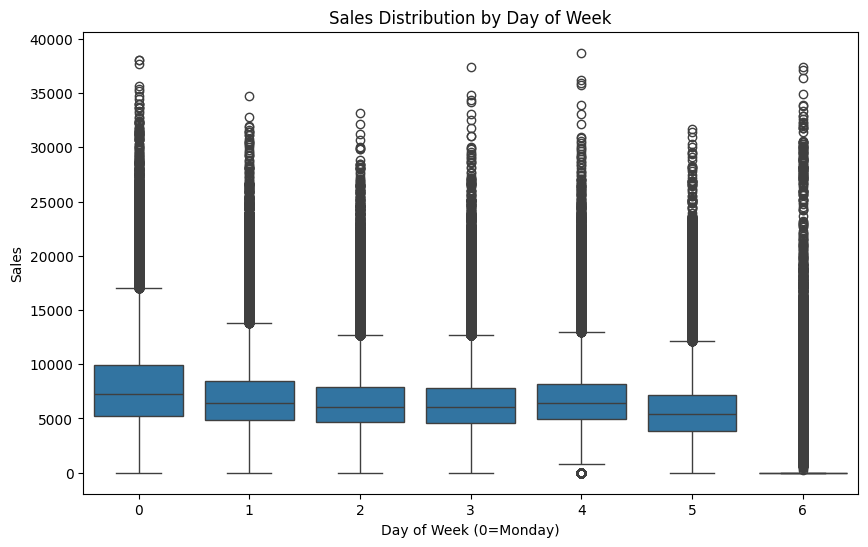

In [7]:
data['DayOfWeek'] = data['Date'].dt.dayofweek
plt.figure(figsize=(10, 6))
sns.boxplot(x="DayOfWeek", y="Sales", data=data)
plt.title("Sales Distribution by Day of Week")
plt.xlabel("Day of Week (0=Monday)")
plt.ylabel("Sales")
plt.show()

##### Data Cleaning

In [8]:
data.dtypes

Store                                 int64
DayOfWeek                             int32
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

In [9]:
print(data.describe(include='all'))
print(data.isnull().sum())

                Store      DayOfWeek                           Date  \
count   914629.000000  914629.000000                         914629   
unique            NaN            NaN                            NaN   
top               NaN            NaN                            NaN   
freq              NaN            NaN                            NaN   
mean       558.477923       2.996935  2014-02-21 18:53:54.394710784   
min          1.000000       0.000000            2013-01-01 00:00:00   
25%        280.000000       1.000000            2013-07-25 00:00:00   
50%        558.000000       3.000000            2014-02-15 00:00:00   
75%        838.000000       5.000000            2014-09-21 00:00:00   
max       1115.000000       6.000000            2015-04-30 00:00:00   
std        321.912653       1.998012                            NaN   

                Sales      Customers           Open          Promo  \
count   914629.000000  914629.000000  914629.000000  914629.000000   
unique 

In [10]:
# Convert StateHoliday to string for consistency
data['StateHoliday'] = data['StateHoliday'].astype(str)

In [11]:
# Fill missing CompetitionDistance with median
data["CompetitionDistance"].fillna(data["CompetitionDistance"].median(), inplace=True)

# Fill missing CompetitionOpenSinceMonth and CompetitionOpenSinceYear.
data["CompetitionOpenSinceMonth"].fillna(0, inplace=True)
data["CompetitionOpenSinceYear"].fillna(0, inplace=True)


C:\Users\MLE\AppData\Local\Temp\ipykernel_1224\1935028322.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["CompetitionDistance"].fillna(data["CompetitionDistance"].median(), inplace=True)
C:\Users\MLE\AppData\Local\Temp\ipykernel_1224\1935028322.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [12]:
# Fill missing values for Promo2 related fields
data["Promo2"].fillna(0, inplace=True)
data["Promo2SinceWeek"].fillna(0, inplace=True)
data["Promo2SinceYear"].fillna(0, inplace=True)
data["PromoInterval"].fillna("None", inplace=True)

C:\Users\MLE\AppData\Local\Temp\ipykernel_1224\4221702795.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Promo2"].fillna(0, inplace=True)
C:\Users\MLE\AppData\Local\Temp\ipykernel_1224\4221702795.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing

In [13]:
# For any other numeric fields have missing values, fill with median
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].median(), inplace=True)

In [14]:
data['StateHoliday'].unique()

array(['0', 'b', 'a', 'c'], dtype=object)

In [15]:
#perform encoding on StateHoliday column

data.loc[data['StateHoliday'] == '0', 'StateHoliday'] = 0
data.loc[data['StateHoliday'] == 'a', 'StateHoliday'] = 1
data.loc[data['StateHoliday'] == 'b', 'StateHoliday'] = 2
data.loc[data['StateHoliday'] == 'c', 'StateHoliday'] = 3

In [16]:
data['StateHoliday'] = data['StateHoliday'].astype(int)

In [17]:
data.dtypes

Store                                 int64
DayOfWeek                             int32
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                          int64
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

#### Feature Engineering

In [18]:
#Fix Dates

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['IsWeekend'] = data['DayOfWeek'].isin([5,6]).astype(int)

In [19]:
# one-hot encoding for StoreType and Assortment
categorical_features = ['StoreType', 'Assortment']
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)

In [20]:
#Create a binary indicator for competition activity
data['HasCompetition'] = data['CompetitionDistance'].notnull().astype(int)

In [21]:
# Process promotion interval
# 1. If there are missing/null values, replace them with an empty string
data['PromoInterval'].fillna('', inplace=True)

# 2. Define the possible months
possible_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# 3. Create a new column for each month
for month in possible_months:
    col_name = f"Promo_{month}"
    data[col_name] = data['PromoInterval'].apply(lambda x: 1 if month in x.split(',') else 0)

C:\Users\MLE\AppData\Local\Temp\ipykernel_1224\3042423460.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['PromoInterval'].fillna('', inplace=True)


In [23]:
# Drop columns
drop_cols = ['Date', 'Customers', 'PromoInterval']
data.drop(columns=drop_cols, inplace=True)



In [24]:
# Drop duplicates if any
data.drop_duplicates(inplace=True)

In [25]:
# Inspect the cleaned data
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914629 entries, 0 to 914628
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      914629 non-null  int64  
 1   DayOfWeek                  914629 non-null  int32  
 2   Sales                      914629 non-null  int64  
 3   Open                       914629 non-null  int64  
 4   Promo                      914629 non-null  int64  
 5   StateHoliday               914629 non-null  int64  
 6   SchoolHoliday              914629 non-null  int64  
 7   CompetitionDistance        914629 non-null  float64
 8   CompetitionOpenSinceMonth  914629 non-null  float64
 9   CompetitionOpenSinceYear   914629 non-null  float64
 10  Promo2                     914629 non-null  int64  
 11  Promo2SinceWeek            914629 non-null  float64
 12  Promo2SinceYear            914629 non-null  float64
 13  Year                       91

### Machine Learning training

#### Splitting data

In [26]:
from sklearn.model_selection import train_test_split

# Assuming Sales is the target
X = data.drop("Sales", axis=1)
y = data["Sales"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#### Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred_lr = lr.predict(X_val)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
mae_lr = mean_absolute_error(y_val, y_pred_lr)
print("Linear Regression - RMSE: {:.2f}, MAE: {:.2f}".format(rmse_lr, mae_lr))

Linear Regression - RMSE: 2499.38, MAE: 1751.78


#### Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf = mean_absolute_error(y_val, y_pred_rf)
print("Random Forest - RMSE: {:.2f}, MAE: {:.2f}".format(rmse_rf, mae_rf))

Random Forest - RMSE: 836.61, MAE: 485.45


#### XGBoost

In [29]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
print("XGBoost - RMSE: {:.2f}, MAE: {:.2f}".format(rmse_xgb, mae_xgb))


XGBoost - RMSE: 1101.61, MAE: 770.27
